## IMPORTING DATA FILE

In [ ]:
import pandas as pd

# Load jsonl file
df = pd.read_json("problems_data.jsonl", lines=True)

# Show basic info
print(df.shape)
df.head()


(4112, 8)


,title,description,input_description,output_description,sample_io,problem_class,problem_score,url
0,Uuu,Unununium (Uuu) was the name of the chemical\n...,The input consists of one line with two intege...,The output consists of $M$ lines where the $i$...,"[{'input': '7 10', 'output': '1 2 2 3 1 3 3 4 ...",hard,9.7,https://open.kattis.com/problems/uuu
1,House Building,A number of eccentrics from central New York h...,"The input consists of $10$ test cases, which a...",Print $K$ lines with\n the positions of the...,"[{'input': '0 2 3 2 50 60 50 30 50 40', 'outpu...",hard,9.7,https://open.kattis.com/problems/husbygge
2,Mario or Luigi,Mario and Luigi are playing a game where they ...,,,"[{'input': '', 'output': ''}]",hard,9.6,https://open.kattis.com/problems/marioorluigi
3,The Wire Ghost,Žofka is bending a copper wire. She starts wit...,The first line contains two integers $L$ and $...,The output consists of a single line consistin...,"[{'input': '4 3 3 C 2 C 1 C', 'output': 'GHOST...",hard,9.6,https://open.kattis.com/problems/thewireghost
4,Barking Up The Wrong Tree,"Your dog Spot is let loose in the park. Well, ...",The first line of input consists of two intege...,Write a single line containing the length need...,"[{'input': '2 0 10 0 10 10', 'output': '14.14'...",hard,9.6,https://open.kattis.com/problems/barktree


In [ ]:
df.columns


Index(['title', 'description', 'input_description', 'output_description',
       'sample_io', 'problem_class', 'problem_score', 'url'],
      dtype='object')

##DATA HANDLING

In [ ]:
df.isnull().sum()


,0
title,0
description,0
input_description,0
output_description,0
sample_io,0
problem_class,0
problem_score,0
url,0


In [ ]:
# Check duplicates ignoring raw list column
df.drop(columns=['sample_io']).duplicated().sum()


np.int64(1)

In [ ]:
# Remove duplicate rows (ignoring raw sample_io column logic already applied)
df = df.drop_duplicates(subset=[
    'title',
    'description',
    'input_description',
    'output_description',
    'problem_class',
    'problem_score'
]).reset_index(drop=True)

print(df.shape)


(4111, 8)


In [ ]:
df['problem_class'].value_counts(), df['problem_score'].describe()


(problem_class
 hard      1940
 medium    1405
 easy       766
 Name: count, dtype: int64,
 count    4111.000000
 mean        5.114352
 std         2.177928
 min         1.100000
 25%         3.300000
 50%         5.200000
 75%         6.900000
 max         9.700000
 Name: problem_score, dtype: float64)

## DATA PREPROCESSING

In [ ]:
# Convert sample_io (list) into text safely
def convert_sample_io(sample):
    if isinstance(sample, list):
        text = ""
        for ex in sample:
            inp = ex.get("input", "")
            out = ex.get("output", "")
            text += f" Input: {inp} Output: {out} "
        return text
    return ""

df['sample_io_text'] = df['sample_io'].apply(convert_sample_io)


In [ ]:
# Fill missing values
for col in ['title', 'description', 'input_description', 'output_description']:
    df[col] = df[col].fillna("")

# Combine all text
df['combined_text'] = (
    df['title'] + " " +
    df['description'] + " " +
    df['input_description'] + " " +
    df['output_description'] + " " +
    df['sample_io_text']
)

df[['combined_text']].head()


,combined_text
0,Uuu Unununium (Uuu) was the name of the chemic...
1,House Building A number of eccentrics from cen...
2,Mario or Luigi Mario and Luigi are playing a g...
3,The Wire Ghost Žofka is bending a copper wire....
4,Barking Up The Wrong Tree Your dog Spot is let...


In [ ]:
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Replace newlines and tabs with space
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

df['clean_text'] = df['combined_text'].apply(clean_text)

# Check result
df[['clean_text']].head()


,clean_text
0,uuu unununium (uuu) was the name of the chemic...
1,house building a number of eccentrics from cen...
2,mario or luigi mario and luigi are playing a g...
3,the wire ghost žofka is bending a copper wire....
4,barking up the wrong tree your dog spot is let...


## EXPLORATORY DATA ANALYSIS

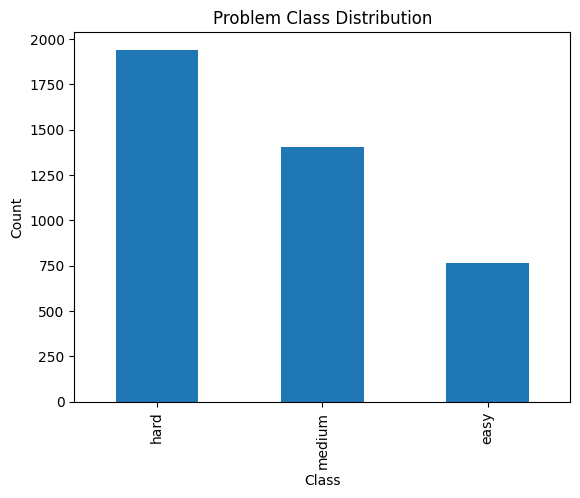

In [ ]:
import matplotlib.pyplot as plt

df['problem_class'].value_counts().plot(kind='bar')
plt.title("Problem Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


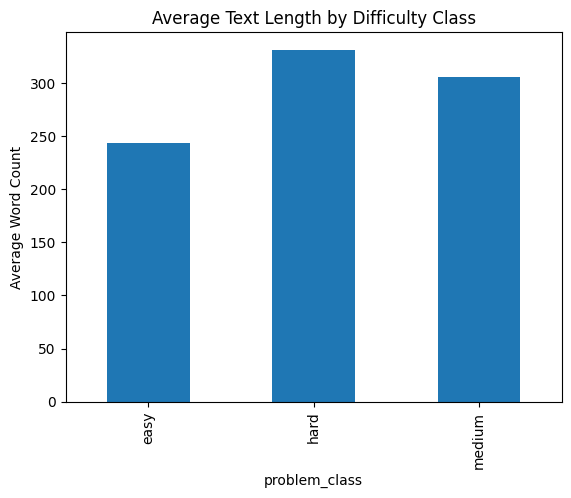

In [ ]:
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

df.groupby('problem_class')['text_length'].mean().plot(kind='bar')
plt.title("Average Text Length by Difficulty Class")
plt.ylabel("Average Word Count")
plt.show()


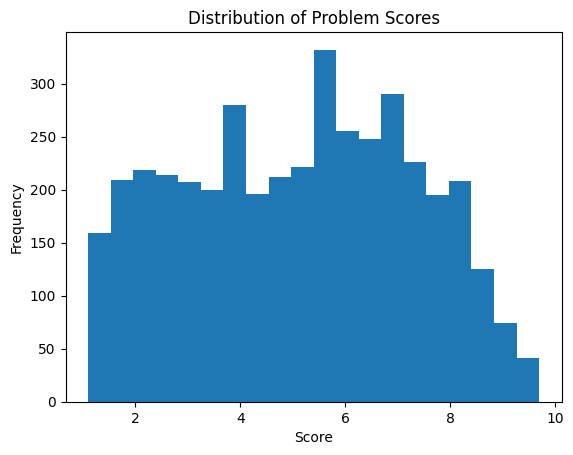

In [ ]:
df['problem_score'].plot(kind='hist', bins=20)
plt.title("Distribution of Problem Scores")
plt.xlabel("Score")
plt.show()


##TRAIN TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y_class = df['problem_class']
y_score = df['problem_score']

X_train, X_test, y_class_train, y_class_test, y_score_train, y_score_test = train_test_split(
    X,
    y_class,
    y_score,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print(X_train.shape, X_test.shape)


(3288,) (823,)


## FEATURE EXTRACTION

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,     # limit vocabulary size
    ngram_range=(1, 2),    # use unigrams + bigrams
    stop_words='english'  # remove very common words
)

# Fit ONLY on training text
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test text
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)


(3288, 5000)
(823, 5000)


## CLASSIFICATION MODELS

###1) Logistic Regression Classification

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create classifier with class imbalance handling
clf = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)

# Train model
clf.fit(X_train_tfidf, y_class_train)


LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)

In [ ]:
y_class_pred = clf.predict(X_test_tfidf)


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_class_test, y_class_pred)
print("Classification Accuracy:", accuracy)


Classification Accuracy: 0.46780072904009723


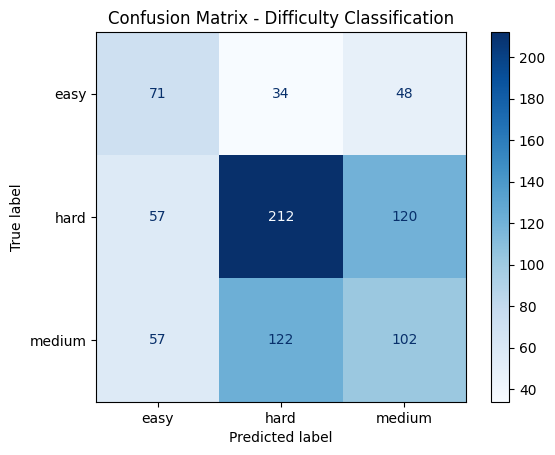

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_class_test, y_class_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Difficulty Classification")
plt.show()


###2) SVM Classification

In [ ]:
from sklearn.svm import LinearSVC

svm_clf = LinearSVC(
    class_weight='balanced',
    random_state=42
)

svm_clf.fit(X_train_tfidf, y_class_train)


LinearSVC(class_weight='balanced', random_state=42)

In [ ]:
y_svm_pred = svm_clf.predict(X_test_tfidf)


In [ ]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_class_test, y_svm_pred)
print("SVM Classification Accuracy:", svm_accuracy)


SVM Classification Accuracy: 0.48602673147023084


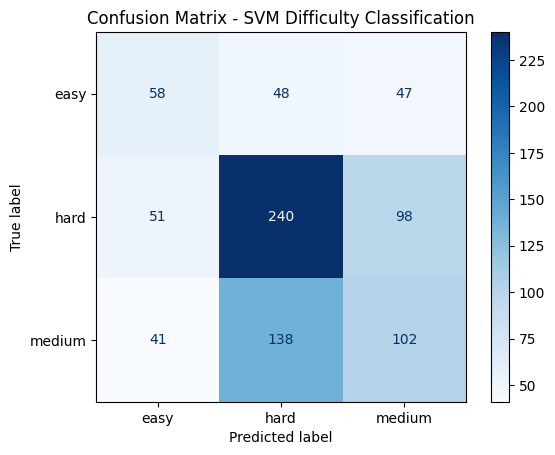

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_class_test, y_svm_pred, labels=svm_clf.classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_clf.classes_)

disp_svm.plot(cmap='Blues')
plt.title("Confusion Matrix - SVM Difficulty Classification")
plt.show()


###3) RandomForest Classification

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_clf.fit(X_train_tfidf, y_class_train)


RandomForestClassifier(class_weight='balanced', max_depth=30, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [ ]:
rf_pred = rf_clf.predict(X_test_tfidf)

rf_accuracy = accuracy_score(y_class_test, rf_pred)
print("Random Forest Classification Accuracy:", rf_accuracy)


Random Forest Classification Accuracy: 0.5309842041312273


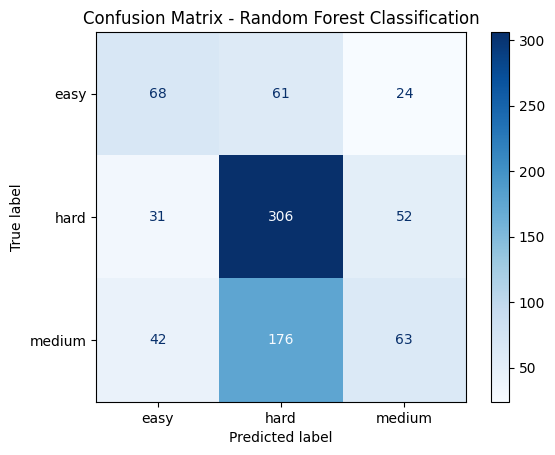

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_class_test, rf_pred, labels=rf_clf.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_clf.classes_)

disp_rf.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest Classification")
plt.show()


###4) Xgboost Classification

In [ ]:
!pip install xgboost


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_class_train_enc = label_encoder.fit_transform(y_class_train)
y_class_test_enc = label_encoder.transform(y_class_test)

print("Class mapping:")
for cls, idx in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{cls} -> {idx}")


Class mapping:
easy -> 0
hard -> 1
medium -> 2


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb_clf = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train_tfidf, y_class_train_enc)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=3, ...)

In [ ]:
xgb_pred_enc = xgb_clf.predict(X_test_tfidf)

xgb_accuracy = accuracy_score(y_class_test_enc, xgb_pred_enc)
print("XGBoost Classification Accuracy:", xgb_accuracy)


XGBoost Classification Accuracy: 0.5103280680437424


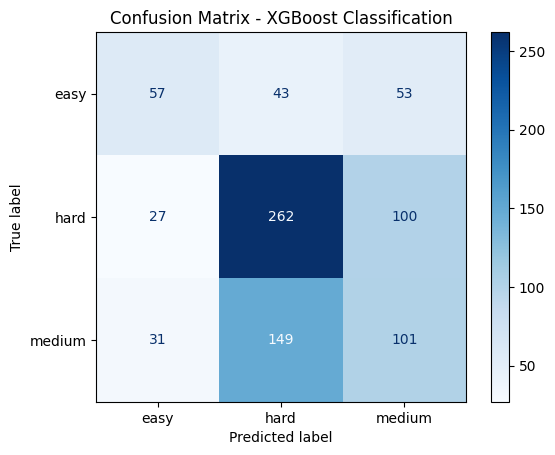

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_xgb = confusion_matrix(y_class_test_enc, xgb_pred_enc)
disp_xgb = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=label_encoder.classes_
)

disp_xgb.plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost Classification")
plt.show()


###5) LightGBM Classification

In [ ]:
!pip install lightgbm


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score


In [ ]:
lgbm_clf = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=300,
    learning_rate=0.1,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

lgbm_clf.fit(X_train_tfidf, y_class_train_enc)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.083362 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 80567
[LightGBM] [Info] Number of data points in the train set: 3288, number of used features: 2822
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


LGBMClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
               num_class=3, objective='multiclass', random_state=42)

In [ ]:
lgbm_pred = lgbm_clf.predict(X_test_tfidf)

lgbm_accuracy = accuracy_score(y_class_test_enc, lgbm_pred)
print("LightGBM Classification Accuracy:", lgbm_accuracy)


LightGBM Classification Accuracy: 0.4957472660996355


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


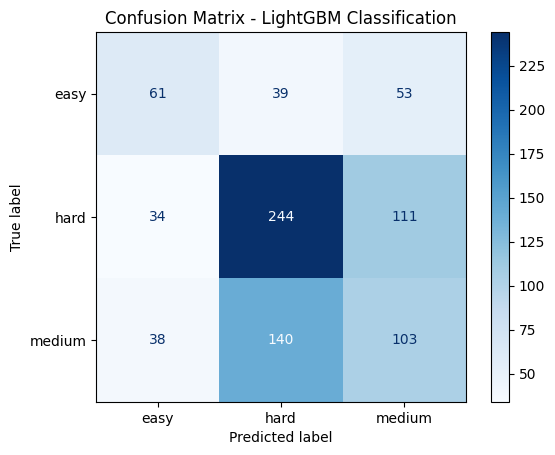

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lgbm = confusion_matrix(y_class_test_enc, lgbm_pred)
disp_lgbm = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm,
    display_labels=label_encoder.classes_
)

disp_lgbm.plot(cmap='Blues')
plt.title("Confusion Matrix - LightGBM Classification")
plt.show()


###6) Catboost Classification

In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.1 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

cat_clf = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=8,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=False
)

cat_clf.fit(X_train_tfidf, y_class_train_enc)


In [ ]:
cat_pred_enc = cat_clf.predict(X_test_tfidf)

cat_accuracy = accuracy_score(y_class_test_enc, cat_pred_enc)
print("CatBoost Classification Accuracy:", cat_accuracy)


CatBoost Classification Accuracy: 0.5066828675577156


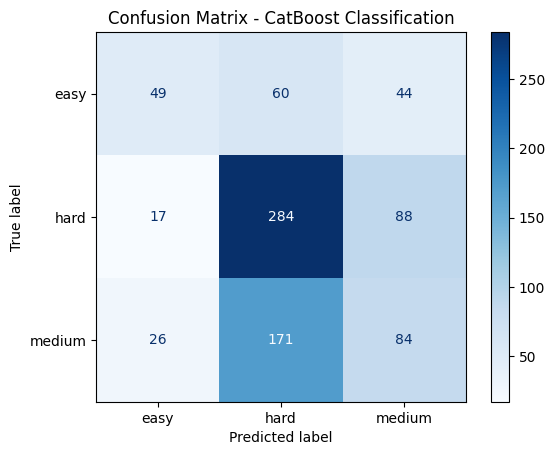

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_cat = confusion_matrix(y_class_test_enc, cat_pred_enc)
disp_cat = ConfusionMatrixDisplay(
    confusion_matrix=cm_cat,
    display_labels=label_encoder.classes_
)

disp_cat.plot(cmap='Blues')
plt.title("Confusion Matrix - CatBoost Classification")
plt.show()


## REGRESSION MODELS

###1) LinearRegression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

lin_reg = LinearRegression()

lin_reg.fit(X_train_tfidf, y_score_train)


LinearRegression()

In [ ]:
lin_pred = lin_reg.predict(X_test_tfidf)

lin_mae = mean_absolute_error(y_score_test, lin_pred)
lin_rmse = np.sqrt(mean_squared_error(y_score_test, lin_pred))

print("Linear Regression MAE:", lin_mae)
print("Linear Regression RMSE:", lin_rmse)


Linear Regression MAE: 3.402227296901885
Linear Regression RMSE: 4.301325109757161


###2) RandomForest Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train_tfidf, y_score_train)


RandomForestRegressor(max_depth=20, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [ ]:
rf_pred = rf_reg.predict(X_test_tfidf)

rf_mae = mean_absolute_error(y_score_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_score_test, rf_pred))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)


Random Forest MAE: 1.7106777994145659
Random Forest RMSE: 2.0377372739328408


###3) XGBoost Regression

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

xgb_reg = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(X_train_tfidf, y_score_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb_reg.predict(X_test_tfidf)

xgb_mae = mean_absolute_error(y_score_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_score_test, xgb_pred))

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)


XGBoost MAE: 1.744139370593816
XGBoost RMSE: 2.093866022532269


### 4) LightGBM Regression

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

lgbm_reg = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.1,
    max_depth=-1,
    random_state=42,
    n_jobs=-1
)

lgbm_reg.fit(X_train_tfidf, y_score_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.117817 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 80567
[LightGBM] [Info] Number of data points in the train set: 3288, number of used features: 2822
[LightGBM] [Info] Start training from score 5.107877


LGBMRegressor(n_estimators=400, n_jobs=-1, random_state=42)

In [ ]:
lgbm_pred = lgbm_reg.predict(X_test_tfidf)

lgbm_mae = mean_absolute_error(y_score_test, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_score_test, lgbm_pred))

print("LightGBM MAE:", lgbm_mae)
print("LightGBM RMSE:", lgbm_rmse)


LightGBM MAE: 1.7220773229891893
LightGBM RMSE: 2.0967937412854325


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 5) Catboost Regression

In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

cat_reg = CatBoostRegressor(
    iterations=600,
    learning_rate=0.1,
    depth=8,
    loss_function='MAE',
    random_seed=42,
    verbose=False
)

cat_reg.fit(X_train_tfidf, y_score_train)


In [ ]:
cat_pred = cat_reg.predict(X_test_tfidf)

cat_mae = mean_absolute_error(y_score_test, cat_pred)
cat_rmse = np.sqrt(mean_squared_error(y_score_test, cat_pred))

print("CatBoost MAE:", cat_mae)
print("CatBoost RMSE:", cat_rmse)


CatBoost MAE: 1.6871368821169963
CatBoost RMSE: 2.0357712595520456


###6) Gradient Boosting Regression

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train_tfidf, y_score_train)

gbr_pred = gbr.predict(X_test_tfidf)

mae_gbr = mean_absolute_error(y_score_test, gbr_pred)
rmse_gbr = np.sqrt(mean_squared_error(y_score_test, gbr_pred))

print("Gradient Boosting MAE:", mae_gbr)
print("Gradient Boosting RMSE:", rmse_gbr)


Gradient Boosting MAE: 1.71251624771929
Gradient Boosting RMSE: 2.043159358509207


##SAVING MODELS

In [ ]:
import joblib
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(svm_clf, "svm_classifier.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")
cat_reg.save_model("catboost_regressor.cbm")
import os

os.listdir(".")


['.config',
 'WebUI_code.py',
 'tfidf_vectorizer.pkl',
 'svm_classifier.pkl',
 'problems_data.jsonl',
 'catboost_info',
 'catboost_regressor.cbm',
 'label_encoder.pkl',
 'sample_data']

In [ ]:
import joblib

joblib.dump(rf_clf, "rf_classifier.pkl")


['rf_classifier.pkl']

###Web UI

In [ ]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 137.8 MB/s eta 0:00:00


In [ ]:
!pip install pyngrok


In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("37Wf9XDp79VgmnBdhYABn7KzSyY_3vXiyoEwXoFwYDgQpWWrm")


In [ ]:
!streamlit run WebUI_code.py &>/content/logs.txt &


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)


NgrokTunnel: "https://palatelike-jaylen-crumply.ngrok-free.dev" -> "http://localhost:8501"
